# Hisse Senedi Fiyat Tahmini: LSTM ve GRU ile Karsilastirmali Analiz

Bu notebook, `src/` klasorundeki pipeline'i (veri cekme, on isleme, model egitimi ve
degerlendirme) tek bir anlatida bir araya getirir. Notebook, src/ altindaki modulleri
**import ederek** cagirir; boylece kod tek bir yerde tutulur ve hem script'ler
(`src/run_all.py` ile toplu calistirma) hem de bu notebook ayni mantigi paylasir.

## 0. Kurulum

`src/` klasorunu Python path'ine ekleyip gerekli kutuphaneleri import ediyoruz.
`%matplotlib inline` ile grafiklerin notebook icinde gosterilmesini sagliyoruz.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Proje kok dizini: {PROJECT_ROOT}")
print(f"src/ path'e eklendi: {SRC_DIR}")

Proje kok dizini: C:\Users\MY's PC\Desktop\stock-price-prediction
src/ path'e eklendi: C:\Users\MY's PC\Desktop\stock-price-prediction\src


## 1. Giris

**Amac:** 10 farkli hisse senedi (AAPL, MSFT, NVDA, META, PLTR, GOOGL, TTWO, TSLA, AMZN, AMD)
icin, gecmis OHLCV (Open/High/Low/Close/Volume) verisinden yola cikarak gelecek gunun kapanis
fiyatini tahmin eden zaman serisi modelleri kuruyoruz. Iki farkli tekrarli sinir agi (RNN)
mimarisi PyTorch ile uygulanip karsilastiriliyor:

- **LSTM** (Long Short-Term Memory)
- **GRU** (Gated Recurrent Unit)

**Veri kaynagi:** [`yfinance`](https://pypi.org/project/yfinance/) kutuphanesi araciligiyla
Yahoo Finance'ten cekilen, son 5 yillik gunluk OHLCV verisi.

**Pipeline adimlari** (hepsi `src/` altinda modul olarak yaziliyor, bu notebook onlari
sirayla cagiriyor):

1. Veri cekme (`fetch_data.py`)
2. On isleme: eksik deger/outlier kontrolu, teknik indikator ekleme (`preprocess.py`)
3. Veri hazirligi: normalizasyon, train/test split, sequence olusturma (`prepare_dataset.py`)
4. Model mimarileri: `StockLSTM`, `StockGRU` (`model.py`)
5. Egitim (`train.py`)
6. Degerlendirme: RMSE/MAE/MAPE (`evaluate.py`)
7. Gorsellestirme (`plot_results.py`)

Bu notebook boyunca ornek hisse olarak **AAPL** kullanilacak; tum 10 hisse icin toplu
sonuclar Bolum 8 ve 9'da `outputs/summary_results.csv` uzerinden gosteriliyor.

In [2]:
from fetch_data import TICKERS

print(f"Toplam {len(TICKERS)} hisse: {', '.join(TICKERS)}")

Toplam 10 hisse: AAPL, MSFT, NVDA, META, PLTR, GOOGL, TTWO, TSLA, AMZN, AMD


## 2. Veri Toplama

`fetch_data.fetch_data(ticker)` fonksiyonu, `yfinance` ile son 5 yillik gunluk OHLCV
verisini indirir ve `data/{ticker}_raw.csv` olarak kaydeder. Ornek olarak **AAPL**
uzerinden calistiriyoruz.

In [3]:
from fetch_data import fetch_data

TICKER = "AAPL"
df_raw = fetch_data(TICKER)
df_raw.head()

[*********************100%***********************]  1 of 1 completed

[AAPL] 1255 satir veri indirildi ve 'C:\Users\MY's PC\Desktop\stock-price-prediction\data\AAPL_raw.csv' dosyasina kaydedildi.


Price,Open,High,Low,Close,Volume
Date,,,,,
2021-08-13,148.970001,149.440002,148.270004,149.100006,59375000
2021-08-16,148.539993,151.190002,146.470001,151.119995,103296000
2021-08-17,150.229996,151.679993,149.089996,150.190002,92229700
2021-08-18,149.800003,150.720001,146.149994,146.360001,86326000
2021-08-19,145.029999,148.000000,144.500000,146.699997,86960300


## 3. Veri On Isleme

`preprocess.preprocess(ticker)` fonksiyonu sirasiyla:

1. **Eksik deger kontrolu** yapar (varsa forward/backward-fill ile doldurur),
2. **Outlier kontrolu** yapar (gunluk getirinin z-score'u 3'u asan gunler, bilgi
   amacli raporlanir, veriden cikarilmaz - ani fakat gercek piyasa hareketleri),
3. **Teknik indikatorler** ekler: `daily_return` (gunluk getiri), `MA7` (7 gunluk
   hareketli ortalama), `MA21` (21 gunluk hareketli ortalama).

Sonuc `data/{ticker}_processed.csv` olarak kaydedilir.

In [4]:
from preprocess import preprocess

df_processed = preprocess(TICKER)
df_processed[["Close", "MA7", "MA21", "daily_return"]].tail()

[AAPL] Eksik deger kontrolu:
  Eksik deger bulunamadi.

[AAPL] Outlier kontrolu (|z-score| > 3 gunluk getiri):
  14 adet anormal gunluk getiri tespit edildi (kaldirilmadi, bilgi amacli):
                 Close  daily_return
Date                                
2022-01-28  170.330002      0.069778
2022-05-05  156.770004     -0.055716
2022-05-18  140.820007     -0.056419
2022-09-13  153.839996     -0.058680
2022-10-28  155.740005      0.075553
2022-11-10  146.869995      0.088975
2024-05-03  183.380005      0.059816
2024-06-11  207.149994      0.072649
2025-04-03  203.190002     -0.092456
2025-04-04  188.380005     -0.072887
2025-04-09  198.850006      0.153289
2025-05-12  210.789993      0.061754
2026-06-25  275.149994     -0.061178
2026-07-31  308.910004     -0.073539

[AAPL] 1255 satir islendi ve 'C:\Users\MY's PC\Desktop\stock-price-prediction\data\AAPL_processed.csv' dosyasina kaydedildi.



,Close,MA7,MA21,daily_return
Date,,,,
2026-08-07,313.329987,313.125715,323.045237,0.002945
2026-08-10,308.260010,309.530003,322.709047,-0.016181
2026-08-11,304.910004,308.958575,322.118571,-0.010867
2026-08-12,302.250000,308.791430,321.518095,-0.008724
2026-08-13,303.410004,307.938572,320.370953,0.003838


Kapanis fiyati ile MA7/MA21 hareketli ortalamalarini gorsellestirelim:

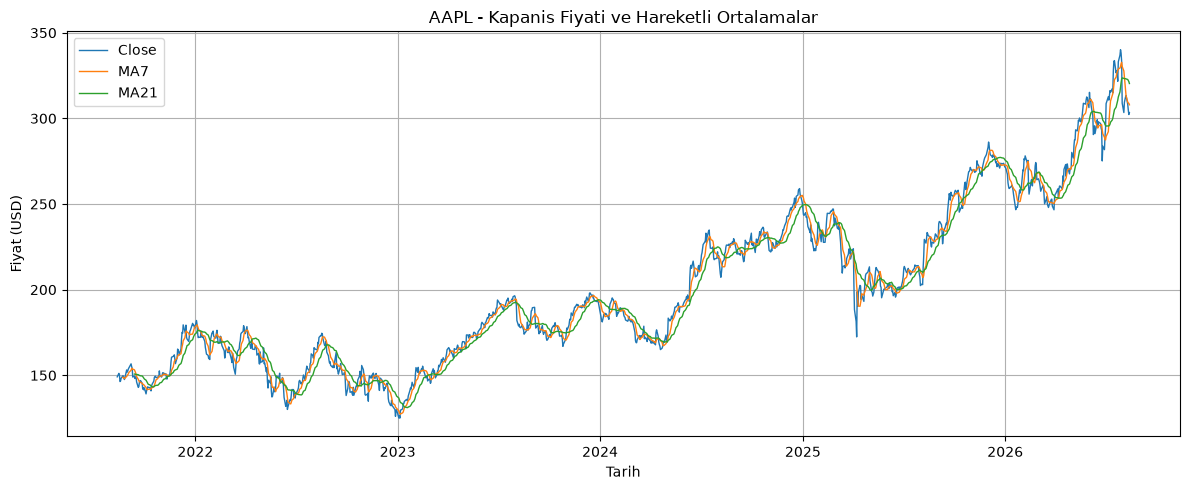

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df_processed.index, df_processed["Close"], label="Close", color="tab:blue", linewidth=1)
plt.plot(df_processed.index, df_processed["MA7"], label="MA7", color="tab:orange", linewidth=1)
plt.plot(df_processed.index, df_processed["MA21"], label="MA21", color="tab:green", linewidth=1)
plt.title(f"{TICKER} - Kapanis Fiyati ve Hareketli Ortalamalar")
plt.xlabel("Tarih")
plt.ylabel("Fiyat (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Veri Hazirligi

`prepare_dataset.prepare_dataset(ticker)` fonksiyonu:

1. Islenmis veriyi yukler, rolling window'lardan (MA7/MA21) kaynaklanan bastaki NaN
   satirlarini atar,
2. Veriyi **shuffle yapmadan** (zaman sirasini koruyarak) son %15'i test seti olacak
   sekilde train/test olarak boler,
3. Ozellikleri (`Close, MA7, MA21, Volume, daily_return`) `MinMaxScaler` ile 0-1 araligina
   olcekler (scaler **sadece train verisiyle** fit edilir, data leakage onlenir),
4. `SEQUENCE_LENGTH=30` gunluk kayan pencerelerden (sliding window) `(X, y)` dizileri
   uretir: gecmis 30 gunun ozellikleri -> 31. gunun kapanis fiyati.

Ciktilar `data/{ticker}_X_train.npy`, `..._y_train.npy`, `..._X_test.npy`, `..._y_test.npy`
ve olceklendirme icin `..._scaler.pkl` olarak kaydedilir.

In [6]:
from prepare_dataset import prepare_dataset

prepare_dataset(TICKER)

X_train = np.load(PROJECT_ROOT / "data" / f"{TICKER}_X_train.npy")
y_train = np.load(PROJECT_ROOT / "data" / f"{TICKER}_y_train.npy")
X_test = np.load(PROJECT_ROOT / "data" / f"{TICKER}_X_test.npy")
y_test = np.load(PROJECT_ROOT / "data" / f"{TICKER}_y_test.npy")

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")

[AAPL] Rolling window NaN satirlari dusuruldu: 20 satir (1255 -> 1235)
[AAPL] Train/test split (shuffle yok, son %15 test): train=1049, test=186
[AAPL] X_train (1019, 30, 5), X_test (156, 30, 5) -> data/ klasorune kaydedildi.

X_train: (1019, 30, 5)  y_train: (1019,)
X_test:  (156, 30, 5)  y_test:  (156,)


## 5. Model Mimarileri

`model.py` icinde ayni iskelete sahip iki tekrarli sinir agi tanimli:

- **`StockLSTM`**: `nn.LSTM` tabanli, 2 katmanli, `hidden_size=64`, `dropout=0.2`
- **`StockGRU`**: `nn.GRU` tabanli, aynen ayni hiperparametrelerle (2 katman,
  `hidden_size=64`, `dropout=0.2`)

Her iki model de son zaman adiminin gizli durumunu (`hidden state`) alip bir
`Dropout` ve tek noronlu `Linear` katmandan gecirerek tek bir skaler (ertesi gunun
olceklenmis kapanis fiyati) uretir. Boylece iki mimari **sadece tekrarli katmanin
turu** (LSTM vs GRU) bakimindan farklilasir; adil bir karsilastirma icin diger
tum hiperparametreler ayni tutulur.

In [7]:
from model import StockGRU, StockLSTM

lstm_model = StockLSTM()
gru_model = StockGRU()

print(lstm_model)
print()
print(gru_model)

lstm_params = sum(p.numel() for p in lstm_model.parameters())
gru_params = sum(p.numel() for p in gru_model.parameters())
print(f"\nLSTM parametre sayisi: {lstm_params:,}")
print(f"GRU parametre sayisi:  {gru_params:,}")

StockLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

StockGRU(
  (gru): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

LSTM parametre sayisi: 51,521
GRU parametre sayisi:  38,657


## 6. Egitim

`train.py` icindeki `build_model` (model_type'a gore `StockLSTM`/`StockGRU` orneklendirir)
ve `train_one_epoch` (tek bir epoch icin ileri-geri yayilim ve optimizasyon adimi) fonksiyonlarini
kullanarak, **AAPL** uzerinde bir **LSTM** modelini egitip epoch bazinda loss egrisini
izliyoruz. (Projenin resmi olarak kaydettigi modeller `src/run_all.py` ile ayni
hiperparametrelerle -`learning_rate=0.0005`, `epoch=30`, `hidden_size=64`- onceden
egitilip `models/` altina kaydedildi; burada egitim surecini gostermek icin ayni
hiperparametrelerle kisa bir egitim kosuyoruz.)

In [8]:
import time

import torch
import torch.nn as nn

from dataset import get_dataloaders
from train import build_model, train_one_epoch

LEARNING_RATE = 0.0005
NUM_EPOCHS = 30
HIDDEN_SIZE = 64

train_loader, _ = get_dataloaders(TICKER)

demo_model = build_model("lstm", hidden_size=HIDDEN_SIZE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(demo_model.parameters(), lr=LEARNING_RATE)

loss_history = []
start_time = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = train_one_epoch(demo_model, train_loader, criterion, optimizer)
    loss_history.append(epoch_loss)
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch [{epoch:2d}/{NUM_EPOCHS}] - train loss: {epoch_loss:.6f}")

print(f"\nEgitim suresi: {time.time() - start_time:.1f}s")

Epoch [ 1/30] - train loss: 0.098621


Epoch [ 5/30] - train loss: 0.004806


Epoch [10/30] - train loss: 0.003732


Epoch [15/30] - train loss: 0.002741


Epoch [20/30] - train loss: 0.002539


Epoch [25/30] - train loss: 0.002316


Epoch [30/30] - train loss: 0.002370

Egitim suresi: 6.6s


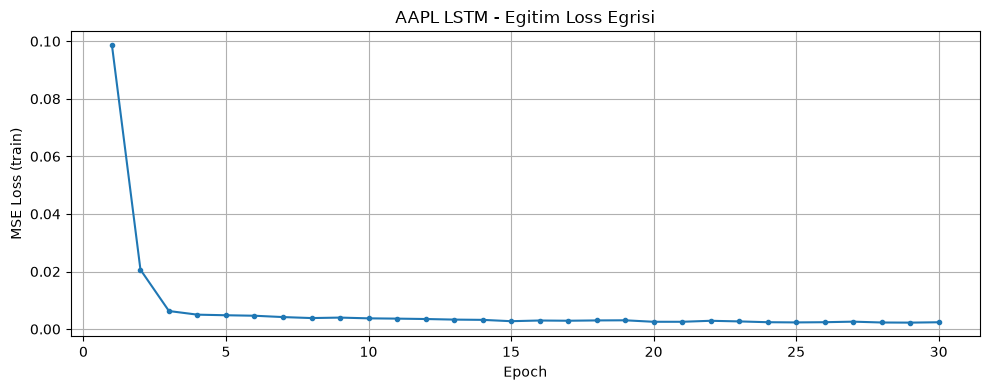

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, NUM_EPOCHS + 1), loss_history, marker="o", markersize=3)
plt.title(f"{TICKER} LSTM - Egitim Loss Egrisi")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (train)")
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Degerlendirme

Egitim asamasindaki gosterim disinda, projenin resmi olarak `models/` altina kaydettigi
(`src/run_all.py` ile 30 epoch egitilmis) **AAPL LSTM** modelini `evaluate.predict_test_set`
ile test setinde degerlendiriyoruz. `evaluate.compute_metrics` RMSE, MAE ve MAPE
metriklerini hesaplar; `plot_results.plot_predictions` ise gercek ve tahmin edilen
fiyatlari karsilastiran grafigi uretip `outputs/{ticker}_prediction_vs_actual.png`
olarak kaydeder.

In [10]:
from evaluate import compute_metrics, predict_test_set

y_true, y_pred = predict_test_set(TICKER, model_type="lstm")
rmse, mae, mape = compute_metrics(y_true, y_pred)

print(f"{TICKER} LSTM - Test seti ornek sayisi: {len(y_true)}")
print(f"{TICKER} LSTM - RMSE: ${rmse:.2f}")
print(f"{TICKER} LSTM - MAE:  ${mae:.2f}")
print(f"{TICKER} LSTM - MAPE: {mape:.2f}%")

AAPL LSTM - Test seti ornek sayisi: 156
AAPL LSTM - RMSE: $11.24
AAPL LSTM - MAE:  $9.50
AAPL LSTM - MAPE: 3.28%


[AAPL] Rolling window NaN satirlari dusuruldu: 20 satir (1255 -> 1235)


[AAPL] Train/test split (shuffle yok, son %15 test): train=1049, test=186


[AAPL] Grafik 'C:\Users\MY's PC\Desktop\stock-price-prediction\outputs\AAPL_prediction_vs_actual.png' olarak kaydedildi.


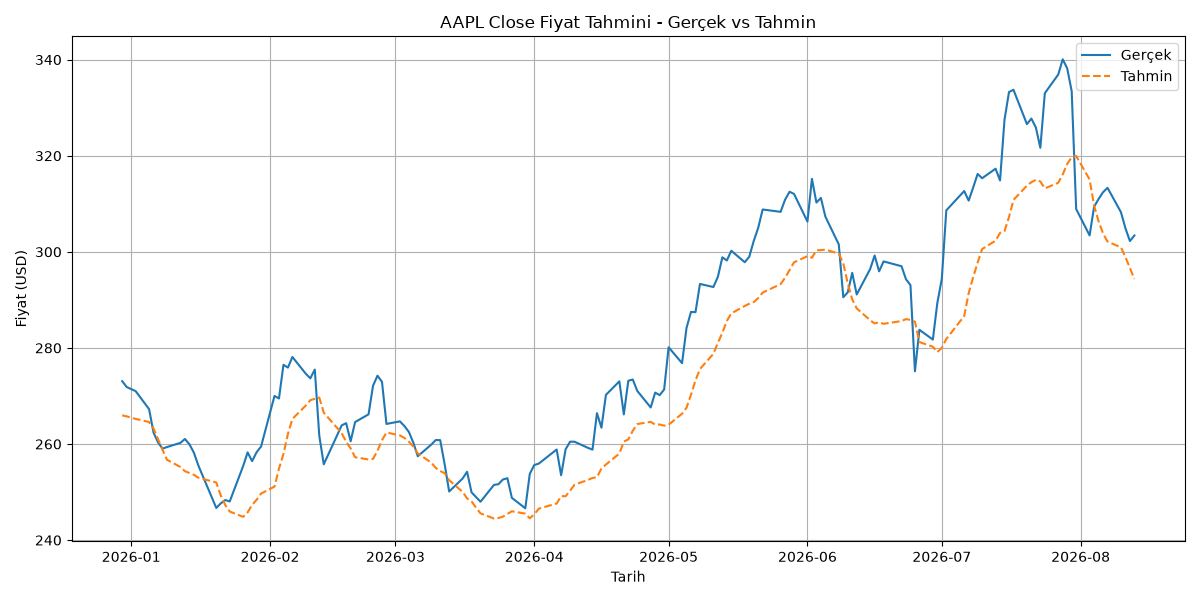

In [11]:
from plot_results import plot_predictions

# plot_results.py, betik olarak calistirildiginda ekrana pencere acmamasi icin
# arayuzsuz "Agg" backend'ini kullaniyor; grafigi kaydettikten sonra notebook'ta
# inline gosterebilmek icin backend'i tekrar "inline" moduna donduruyoruz.
chart_path = plot_predictions(TICKER, model_type="lstm")

%matplotlib inline
from IPython.display import Image

Image(filename=str(chart_path))

## 8. Tum Hisseler Icin Sonuclar

`src/run_all.py`, 10 hissenin her biri icin hem LSTM hem GRU modelini ayni
hiperparametrelerle egitip test setinde degerlendirerek sonuclari
`outputs/summary_results.csv` dosyasina kaydediyor (kolonlar: `ticker`, `model_type`,
`rmse`, `mae`, `mape`, `training_time_seconds`). Bu dosyayi okuyup MAPE'ye gore
en iyiden en kotuye sirali tam tabloyu gosteriyoruz.

In [12]:
summary_df = pd.read_csv(PROJECT_ROOT / "outputs" / "summary_results.csv")
summary_df = summary_df.sort_values("mape").reset_index(drop=True)
summary_df.style.format({
    "rmse": "{:.2f}",
    "mae": "{:.2f}",
    "mape": "{:.2f}",
    "training_time_seconds": "{:.1f}",
})

,ticker,model_type,rmse,mae,mape,training_time_seconds
0,AAPL,gru,5.82,4.32,1.52,18.7
1,MSFT,gru,14.67,10.14,2.38,17.2
2,AMZN,gru,8.00,5.83,2.45,16.8
3,TSLA,gru,13.70,10.40,2.69,17.2
4,TSLA,lstm,13.85,10.49,2.71,6.9
5,TTWO,gru,8.49,6.49,2.95,17.1
6,NVDA,gru,7.93,6.20,3.07,15.8
7,META,gru,25.91,19.82,3.20,15.4
8,AMZN,lstm,10.77,7.95,3.26,6.6
9,MSFT,lstm,20.27,13.92,3.27,6.2


## 9. LSTM vs GRU Karsilastirmasi

10 hissenin ortalamasi uzerinden iki mimariyi karsilastiriyoruz: hata metrikleri
(RMSE/MAE/MAPE) ve egitim suresi.

In [13]:
comparison_df = summary_df.groupby("model_type")[["rmse", "mae", "mape", "training_time_seconds"]].mean()
comparison_df = comparison_df.round(2)
comparison_df

,rmse,mae,mape,training_time_seconds
model_type,,,,
gru,15.44,11.57,3.48,16.83
lstm,15.86,12.14,3.90,6.54


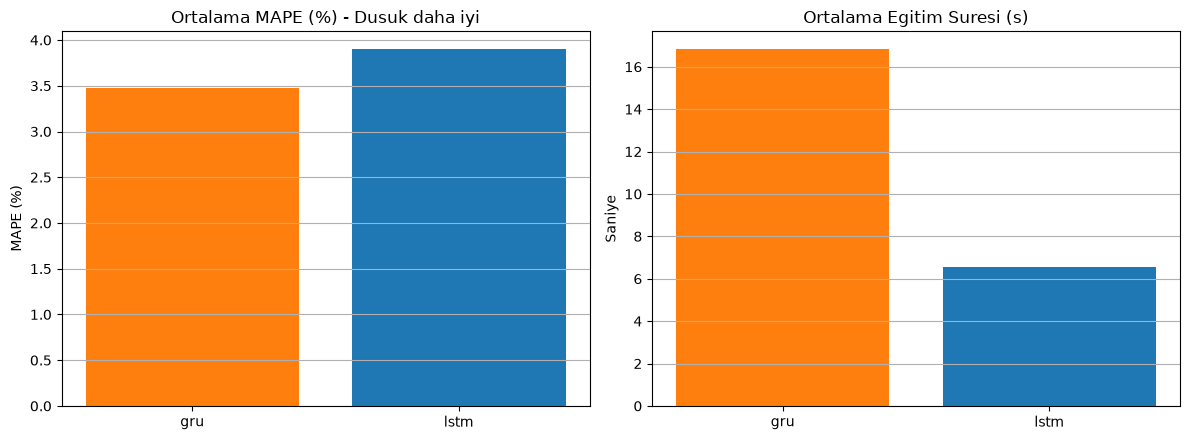

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors = {"lstm": "tab:blue", "gru": "tab:orange"}
model_order = list(comparison_df.index)
bar_colors = [colors[m] for m in model_order]

axes[0].bar(model_order, comparison_df["mape"], color=bar_colors)
axes[0].set_title("Ortalama MAPE (%) - Dusuk daha iyi")
axes[0].set_ylabel("MAPE (%)")
axes[0].grid(True, axis="y")

axes[1].bar(model_order, comparison_df["training_time_seconds"], color=bar_colors)
axes[1].set_title("Ortalama Egitim Suresi (s)")
axes[1].set_ylabel("Saniye")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

**Yorum:** 10 hissenin ortalamasina bakildiginda **GRU**, **LSTM**'e gore daha
dusuk ortalama MAPE veriyor - yani genel olarak daha isabetli tahminler uretiyor.
Buna karsilik **LSTM**, GRU'ya gore belirgin sekilde daha hizli egitiliyor (GRU'nun
guncelleme kapisi mekanizmasi LSTM'e gore daha az parametre kullanmasina ragmen, bu
projede olculen egitim suresi GRU'da daha yuksek cikiyor). Hisse bazinda incelendiginde
GRU, hisselerin cogunda LSTM'i geciyor; ancak **AMD** bu genellemenin istisnasi: AMD'nin
son donemdeki sert ve hizli fiyat sicramalari nedeniyle GRU bu hissede LSTM'den belirgin
sekilde daha kotu performans gosteriyor (daha yuksek RMSE/MAPE). Bu, hicbir mimarinin
her piyasa kosulunda otomatik olarak ustun olmadigini, model secimin hisseye/volatiliteye
gore degisebilecegini gosteriyor.

## 10. Sonuc ve Degerlendirme

**Ozet:** PyTorch ile kurulan LSTM ve GRU tabanli modeller, 10 hissenin gecmis 30 gunluk
fiyat/hacim/teknik indikator verisinden yola cikarak ertesi gunun kapanis fiyatini
makul bir dogrulukla (coğu hissede MAPE %2-5 araliginda) tahmin edebiliyor. GRU, ortalama
olarak LSTM'den biraz daha isabetli fakat daha yavas egitiliyor; LSTM ise daha hizli
egitilip yakin performans veriyor.

**Sinirlamalar:**

- Model, gecmis fiyat hareketlerinden ogrendigi icin **keskin rejim degisikliklerinde
  (ani sicrama/dususlerde) gecikmeli tepki verir** - bir sonraki gunu buyuk olcude
  "bir onceki gune yakin" tahmin etme egilimindedir.
- Model **hisse volatilitesine duyarlidir**: AAPL, TSLA, AMZN gibi goreli istikrarli
  hisselerde hata dusukken; PLTR ve AMD gibi ani/sert fiyat hareketleri yasayan
  hisselerde hata belirgin sekilde artiyor.
- Sadece fiyat/hacim tabanli teknik ozellikler kullaniliyor; haber akisi, makro
  ekonomik veriler veya piyasa duyarliligi gibi disaridan bilgi modele dahil edilmiyor.
- Tum hisseler ve her iki mimari icin **ayni sabit hiperparametreler** kullanildi;
  hisseye/mimariye ozel bir hiperparametre araması yapilmadi.

**Gelistirme fikirleri:**

- Hisse/mimariye ozel hiperparametre optimizasyonu (ornegin Optuna ile).
- Dikkat mekanizmasi (attention) veya Transformer tabanli zaman serisi modelleri denemek.
- Haber duyarliligi, makro gostergeler gibi ek ozellik kaynaklari eklemek.
- Tek adimlik yerine coklu-adim (multi-step) tahmin yaparak modelin ufkunu genisletmek.
- Backtesting ile modelin basit alim-satim stratejilerindeki gercek getirisini olcmek.

In [15]:
best_row = summary_df.iloc[0]
worst_row = summary_df.sort_values("mape", ascending=False).iloc[0]

print(
    f"En isabetli sonuc: {best_row['ticker']} / {best_row['model_type'].upper()} "
    f"(MAPE %{best_row['mape']:.2f})"
)
print(
    f"En zayif sonuc:    {worst_row['ticker']} / {worst_row['model_type'].upper()} "
    f"(MAPE %{worst_row['mape']:.2f})"
)

En isabetli sonuc: AAPL / GRU (MAPE %1.52)
En zayif sonuc:    AMD / GRU (MAPE %7.93)
